# Bird Challenge — BirdNET Score Calibration

**Project:** Savanna Monitoring Pilot (SAVMON) — Lewa, Kenya  
**Reference:** Wood & Kahl (2024) — *Guidelines for appropriate use of BirdNET scores*, Journal of Ornithology

---

### Background

Passive acoustic monitoring (PAM) devices deployed across the Lewa landscape record audio around the clock. That audio is processed by **BirdNET v2.4**, a deep-learning model that listens to every three-second clip and outputs a **confidence score** between 0.1 and 1.0 for each species it thinks it hears.

The intuitive reading of that score — that 0.9 means 90% sure — is wrong. BirdNET's confidence score is an internal signal strength squeezed through a sigmoid function to look like a probability. It is not one. The same score of 0.7 can mean something completely different for two species: for one it might be almost always correct, for another it might still be guessing half the time.

### What this notebook does

1. **Import packages and load data** — 29,491 BirdNET predictions and 551 ornithologist-validated clips
2. **Subset check** — confirm every validation clip exists in the predictions file
3. **EDA** — completeness, dtypes, species breakdown, score range, version consistency
4. **Data cleaning** — fix types, remove nulls and duplicates, add the logit-transformed score
5. **Representativeness checks** — five statistical tests confirming the validation sample is a fair sample of the prediction population
6. **Modelling pipeline** — logistic regression on logit-transformed scores (Wood & Kahl 2024), threshold derivation, diagnostics, and labelling

---
## 1. Package Imports

All imports upfront so dependency issues surface immediately. Grouped by purpose so it is clear what each library is used for.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.special import expit

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, log_loss,
    precision_recall_curve, average_precision_score
)
from sklearn.calibration import calibration_curve

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

print('All packages imported successfully.')

All packages imported successfully.


---
## 2. Data Import

Two input files:
- **`birdnet_predictions.csv`** — every clip where BirdNET fired above its minimum detection threshold (0.1) across all 43 sites. This is the population we ultimately want to label.
- **`validation_results.csv`** — a subset of those clips that an ornithologist listened to and judged correct (outcome = 1) or incorrect (outcome = 0). This is our ground truth for calibration.

We check row counts immediately against expected values: 29,491 predictions and 551 validated clips.

In [2]:
BASE       = os.getcwd()
DATA_BIRDS = os.path.join(BASE, 'Data Birds')
OUT_DIR    = os.path.join(BASE, 'outputs', 'bird')
os.makedirs(OUT_DIR, exist_ok=True)

val  = pd.read_csv(os.path.join(DATA_BIRDS, 'validation_results.csv'))
pred = pd.read_csv(os.path.join(DATA_BIRDS, 'birdnet_predictions.csv'))

val.columns  = val.columns.str.strip()
pred.columns = pred.columns.str.strip()

print(f'Validation set  : {val.shape[0]:,} rows x {val.shape[1]} columns')
print(f'Predictions set : {pred.shape[0]:,} rows x {pred.shape[1]} columns')
print()
display(val.head(3))
display(pred.head(3))

Validation set  : 551 rows x 6 columns
Predictions set : 29,491 rows x 13 columns



,scientificName,commonName,vBirdNET,filename,confidence,outcome
0,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.107_4_RBS21_20230630_190000.wav,0.1070,1
1,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.109_1_RBS14_20230706_010000.wav,0.1090,1
2,Caprimulgus poliocephalus,Abyssinian Nightjar,v2.4,0.110_1_RBS60_20230702_220000.wav,0.1100,1


,selection,view,channel,begin_time_s,end_time_s,low_freq_hz,high_freq_hz,common_name,species_code,confidence,begin_path,file_offset_s,folder
0,1,Spectrogram 1,1,889,892,0,15000,African Black-headed Oriole,abhori1,0.6278,Grid2/RBS02/RBS02_20230622_170000.WAV,889,RBS02
1,2,Spectrogram 1,1,1084,1087,0,15000,African Black-headed Oriole,abhori1,0.3217,Grid2/RBS02/RBS02_20230622_170000.WAV,1084,RBS02
2,1,Spectrogram 1,1,3178,3181,0,15000,Abyssinian Nightjar,abynig1,0.1028,Grid2/RBS02/RBS02_20230622_190000.WAV,3178,RBS02


---
## 3. Subset Check — Does Every Validation Clip Exist in the Predictions?

### Why this comes first

The validation set is supposed to be a sample drawn from the prediction population. Every validated clip should have a corresponding row in the predictions file. If it does not, the two datasets may not be from the same population, which invalidates calibration entirely.

### How we match rows

There is no shared row ID. BirdNET's segments export encodes clip identity in the validation filename:

```
0.107_4_RBS21_20230630_190000.wav
 |    |  |      |         |-- time
 |    |  |      |------------ date
 |    |  |------------------- site (= folder in predictions)
 |    |---------------------- selection count
 |--------------------------- confidence score
```

Composite key: **species + site + source WAV filename + confidence score**.

In [3]:
def parse_val_filename(filename):
    name  = str(filename).replace('.wav', '').replace('.WAV', '')
    parts = name.split('_')
    if len(parts) < 5:
        return None, None, None
    site     = parts[2]
    wav_file = f'{site}_{parts[3]}_{parts[4]}.WAV'
    return parts[0], site, wav_file

val[['val_conf_str', 'val_site', 'val_wav']] = pd.DataFrame(
    val['filename'].apply(parse_val_filename).tolist(),
    index=val.index, columns=['val_conf_str', 'val_site', 'val_wav']
)
pred['pred_wav'] = pred['begin_path'].apply(
    lambda p: os.path.basename(str(p)) if pd.notna(p) else None
)

val['conf_rounded']  = val['confidence'].round(4)
pred['conf_rounded'] = pred['confidence'].round(4)

pred_keys = set(zip(pred['common_name'], pred['folder'], pred['pred_wav'], pred['conf_rounded']))

# Note: validation still uses 'commonName' here — rename happens in Section 5
val['found_in_predictions'] = val.apply(
    lambda r: (r['commonName'], r['val_site'], r['val_wav'], r['conf_rounded']) in pred_keys, axis=1
)

n_matched   = val['found_in_predictions'].sum()
n_unmatched = (~val['found_in_predictions']).sum()

print(f'Matched   : {n_matched} / {len(val)} ({100*n_matched/len(val):.1f}%)')
print(f'Unmatched : {n_unmatched}')

if n_unmatched == 0:
    print('\nAll validation clips confirmed as a subset of the prediction population.')
else:
    print('\nUnmatched clips — investigate before proceeding:')
    display(val[~val['found_in_predictions']][['commonName','confidence','val_site','val_wav','filename']])

print('\nPer-species match rate:')
display(
    val.groupby('commonName')
    .agg(n_total=('found_in_predictions','count'), n_matched=('found_in_predictions','sum'))
    .assign(pct_matched=lambda d: (d['n_matched']/d['n_total']*100).round(1),
            n_unmatched=lambda d: d['n_total']-d['n_matched'])
    .reset_index()
)

Matched   : 32 / 551 (5.8%)
Unmatched : 519

Unmatched clips — investigate before proceeding:


,commonName,confidence,val_site,val_wav,filename
0,Abyssinian Nightjar,0.1070,RBS21,RBS21_20230630_190000.WAV,0.107_4_RBS21_20230630_190000.wav
1,Abyssinian Nightjar,0.1090,RBS14,RBS14_20230706_010000.WAV,0.109_1_RBS14_20230706_010000.wav
2,Abyssinian Nightjar,0.1100,RBS60,RBS60_20230702_220000.WAV,0.110_1_RBS60_20230702_220000.wav
3,Abyssinian Nightjar,0.1130,RBS14,RBS14_20230708_040002.WAV,0.113_3_RBS14_20230708_040002.wav
4,Abyssinian Nightjar,0.1160,RBS55,RBS55_20230701_220000.WAV,0.116_1_RBS55_20230701_220000.wav
...,...,...,...,...,...
546,Three-banded Plover,0.9890,RBS75,RBS75_20230702_080002.WAV,0.989_6_RBS75_20230702_080002.wav
547,Three-banded Plover,0.9910,RBS75,RBS75_20230701_000000.WAV,0.991_1_RBS75_20230701_000000.wav
548,Three-banded Plover,0.9910,RBS75,RBS75_20230707_110002.WAV,0.991_1_RBS75_20230707_110002.wav
549,Three-banded Plover,0.9940,RBS75,RBS75_20230628_160000.WAV,0.994_4_RBS75_20230628_160000.wav



Per-species match rate:


,commonName,n_total,n_matched,pct_matched,n_unmatched
0,Abyssinian Nightjar,150,23,15.3000,127
1,African Black-headed Oriole,150,6,4.0000,144
2,Red-billed Firefinch,101,2,2.0000,99
3,Three-banded Plover,150,1,0.7000,149


---
## 4. EDA — Data Completeness & Quality

Before cleaning or modelling anything, we characterise both datasets as they arrived. Three questions:
1. **Nulls and types?** A null in `confidence` or `outcome` would silently corrupt the model.
2. **Species breakdown?** TP/FP split and score range per species before any decisions are made.
3. **Score range and version consistent?** Out-of-range scores or a version mismatch invalidate thresholds.

### 4.1 Data types, nulls, and unique values

In [4]:
def completeness_report(df, name):
    report = pd.DataFrame({
        'dtype'   : df.dtypes,
        'n_null'  : df.isna().sum(),
        'pct_null': (df.isna().mean() * 100).round(2),
        'n_unique': df.nunique(),
        'example' : df.iloc[0]
    })
    print(f'\n-- {name} ({df.shape[0]:,} rows x {df.shape[1]} cols) --')
    display(report)

completeness_report(val,  'Validation results')
completeness_report(pred, 'BirdNET predictions')


-- Validation results (551 rows x 11 cols) --


,dtype,n_null,pct_null,n_unique,example
scientificName,object,0,0.0000,4,Caprimulgus poliocephalus
commonName,object,0,0.0000,4,Abyssinian Nightjar
vBirdNET,object,0,0.0000,1,v2.4
filename,object,0,0.0000,551,0.107_4_RBS21_20230630_190000.wav
confidence,float64,0,0.0000,342,0.1070
outcome,int64,0,0.0000,2,1
val_conf_str,object,0,0.0000,342,0.107
val_site,object,0,0.0000,32,RBS21
val_wav,object,0,0.0000,353,RBS21_20230630_190000.WAV
conf_rounded,float64,0,0.0000,342,0.1070



-- BirdNET predictions (29,491 rows x 15 cols) --


,dtype,n_null,pct_null,n_unique,example
selection,int64,0,0.0000,270,1
view,object,0,0.0000,1,Spectrogram 1
channel,int64,0,0.0000,1,1
begin_time_s,int64,0,0.0000,2826,889
end_time_s,int64,0,0.0000,2826,892
low_freq_hz,int64,0,0.0000,1,0
high_freq_hz,int64,0,0.0000,1,15000
common_name,object,0,0.0000,4,African Black-headed Oriole
species_code,object,0,0.0000,4,abhori1
confidence,float64,0,0.0000,7939,0.6278


### 4.2 Species breakdown

Key numbers: TP/FP split and score range per species in the validation set; prediction count and site spread in the predictions file. Species with very few validated positives may not support a reliable logistic regression.

In [5]:
print('=== VALIDATION - species counts & class balance ===')
display(
    val.groupby('commonName').agg(
        n_clips     =('outcome','count'),
        n_tp        =('outcome','sum'),
        n_fp        =('outcome', lambda x: (x==0).sum()),
        pct_correct =('outcome', lambda x: round(x.mean()*100,1)),
        score_min   =('confidence','min'),
        score_max   =('confidence','max'),
        score_mean  =('confidence','mean'),
    ).reset_index()
)

print('\n=== PREDICTIONS - species counts & site coverage ===')
display(
    pred.groupby('common_name').agg(
        n_predictions=('confidence','count'),
        n_sites      =('folder','nunique'),
        score_min    =('confidence','min'),
        score_max    =('confidence','max'),
        score_mean   =('confidence','mean'),
    ).reset_index()
)

=== VALIDATION - species counts & class balance ===


,commonName,n_clips,n_tp,n_fp,pct_correct,score_min,score_max,score_mean
0,Abyssinian Nightjar,150,117,33,78.0000,0.1020,1.0000,0.5879
1,African Black-headed Oriole,150,150,0,100.0000,0.1040,0.9890,0.5668
2,Red-billed Firefinch,101,6,95,5.9000,0.1010,0.9070,0.1819
3,Three-banded Plover,150,149,1,99.3000,0.1020,0.9940,0.5725



=== PREDICTIONS - species counts & site coverage ===


,common_name,n_predictions,n_sites,score_min,score_max,score_mean
0,Abyssinian Nightjar,10187,27,0.1000,1.0000,0.4528
1,African Black-headed Oriole,18054,35,0.1000,0.9985,0.3607
2,Red-billed Firefinch,235,31,0.1000,0.9073,0.1804
3,Three-banded Plover,1015,22,0.1002,0.9997,0.3885


### 4.3 Confidence score range check

BirdNET v2.4 applies a minimum threshold of 0.1, so all scores should fall in **[0.1, 1.0]**. Out-of-range rows indicate a version mismatch, manual entry, or parsing error.

In [6]:
for name, df, col in [('Validation', val, 'confidence'), ('Predictions', pred, 'confidence')]:
    oor = df[(df[col] < 0.1) | (df[col] > 1.0)]
    print(f'{name}: scores outside [0.1, 1.0] -> {len(oor)} rows')
    if len(oor):
        display(oor.head())

Validation: scores outside [0.1, 1.0] -> 0 rows
Predictions: scores outside [0.1, 1.0] -> 0 rows


### 4.4 BirdNET version consistency check

Thresholds derived from v2.4 validation data must only be applied to v2.4 predictions. The model architecture changes between versions, so scores are not comparable across them.

In [7]:
print('BirdNET versions in validation set:')
print(val['vBirdNET'].value_counts().to_string())
print('\nBirdNET version for predictions: v2.4 (confirmed from project documentation)')
print('-> Versions match. Safe to apply thresholds derived here to the predictions file.')

BirdNET versions in validation set:
vBirdNET
v2.4    551

BirdNET version for predictions: v2.4 (confirmed from project documentation)
-> Versions match. Safe to apply thresholds derived here to the predictions file.


---
## 5. Data Cleaning

Six documented steps:
1. **Enforce dtypes** — `outcome` to int, `confidence` to float
2. **Drop null confidence rows** — unusable for modelling
3. **Drop null species rows** — cannot be joined to thresholds
4. **Drop exact duplicates** — would inflate sample sizes
5. **Align species name column** — rename `commonName` to `common_name`
6. **Add logit-transformed score** — reverses BirdNET sigmoid compression; required before logistic regression (explained in Section 7, Stage 1)

In [8]:
CLIP_EPS = 1e-6

def safe_logit(c):
    """ln(p/(1-p)) with clipping to avoid +-inf at boundaries."""
    c_clip = np.clip(c, CLIP_EPS, 1 - CLIP_EPS)
    return np.log(c_clip / (1 - c_clip))

# 1. Dtypes
val['outcome']     = val['outcome'].astype(int)
val['confidence']  = pd.to_numeric(val['confidence'],  errors='coerce')
pred['confidence'] = pd.to_numeric(pred['confidence'], errors='coerce')

# 2. Drop null confidence
print(f'Null confidence dropped - val: {val["confidence"].isna().sum()}, pred: {pred["confidence"].isna().sum()}')
val  = val.dropna(subset=['confidence']).reset_index(drop=True)
pred = pred.dropna(subset=['confidence']).reset_index(drop=True)

# 3. Drop null species
val  = val.dropna(subset=['commonName']).reset_index(drop=True)
pred = pred.dropna(subset=['common_name']).reset_index(drop=True)

# 4. Drop exact duplicates
print(f'Duplicates dropped - val: {val.duplicated().sum()}, pred: {pred.duplicated().sum()}')
val  = val.drop_duplicates().reset_index(drop=True)
pred = pred.drop_duplicates().reset_index(drop=True)

# 5. Align species name column
val = val.rename(columns={'commonName': 'common_name'})

# 6. Logit transform
val['logit_score']  = safe_logit(val['confidence'].values)
pred['logit_score'] = safe_logit(pred['confidence'].values)

print(f'\nFinal counts - val: {len(val):,}  pred: {len(pred):,}')

Null confidence dropped - val: 0, pred: 0


Duplicates dropped - val: 0, pred: 0



Final counts - val: 551  pred: 29,491


---
## 6. Representativeness — Is the Validation Sample a Fair Sample of the Prediction Population?

### Why this matters

The calibration model learns `confidence score -> pr(correct)` from the 551 validated clips, then applies that relationship to all 29,491 predictions. This only works if the 551 clips represent the same score distribution, site spread, and detection conditions as the full dataset. A biased validation sample produces a biased threshold.

Wood & Kahl (2024) explicitly recommend validated clips be drawn as a **stratified random sample across the score range**.

| Check | Method | A failure means |
|---|---|---|
| 6.1 Score distribution | KS test | Validation scores from a different distribution |
| 6.2 Score bin coverage | Chi-squared + bar chart | Empty score ranges — threshold extrapolated not empirical |
| 6.3 Site coverage | Set comparison + bar chart | Model may not generalise across all 43 sites |
| 6.4 Prevalence & score separation | TP rate + mean score gap | Artificially balanced sample or no discriminating signal |
| 6.5 Sample size (EPV) | Events-per-variable rule | Too few TPs to fit a reliable logistic regression |

### 6.1 Score Distribution — Kolmogorov-Smirnov Test

Measures the maximum vertical gap between the CDFs of validation scores and prediction scores per species.
- **H0:** Both samples from the same distribution
- **p < 0.05:** Distributions differ — investigate bin coverage (6.2) to see where the gap is and whether it affects the threshold range

,species,n_validation,n_predictions,KS_statistic,p_value,reject_H0_0.05
0,Abyssinian Nightjar,150,10187,0.2141,0.0000,YES
1,African Black-headed Oriole,150,18054,0.3449,0.0000,YES
2,Red-billed Firefinch,101,235,0.0842,0.6590,no
3,Three-banded Plover,150,1015,0.3186,0.0000,YES


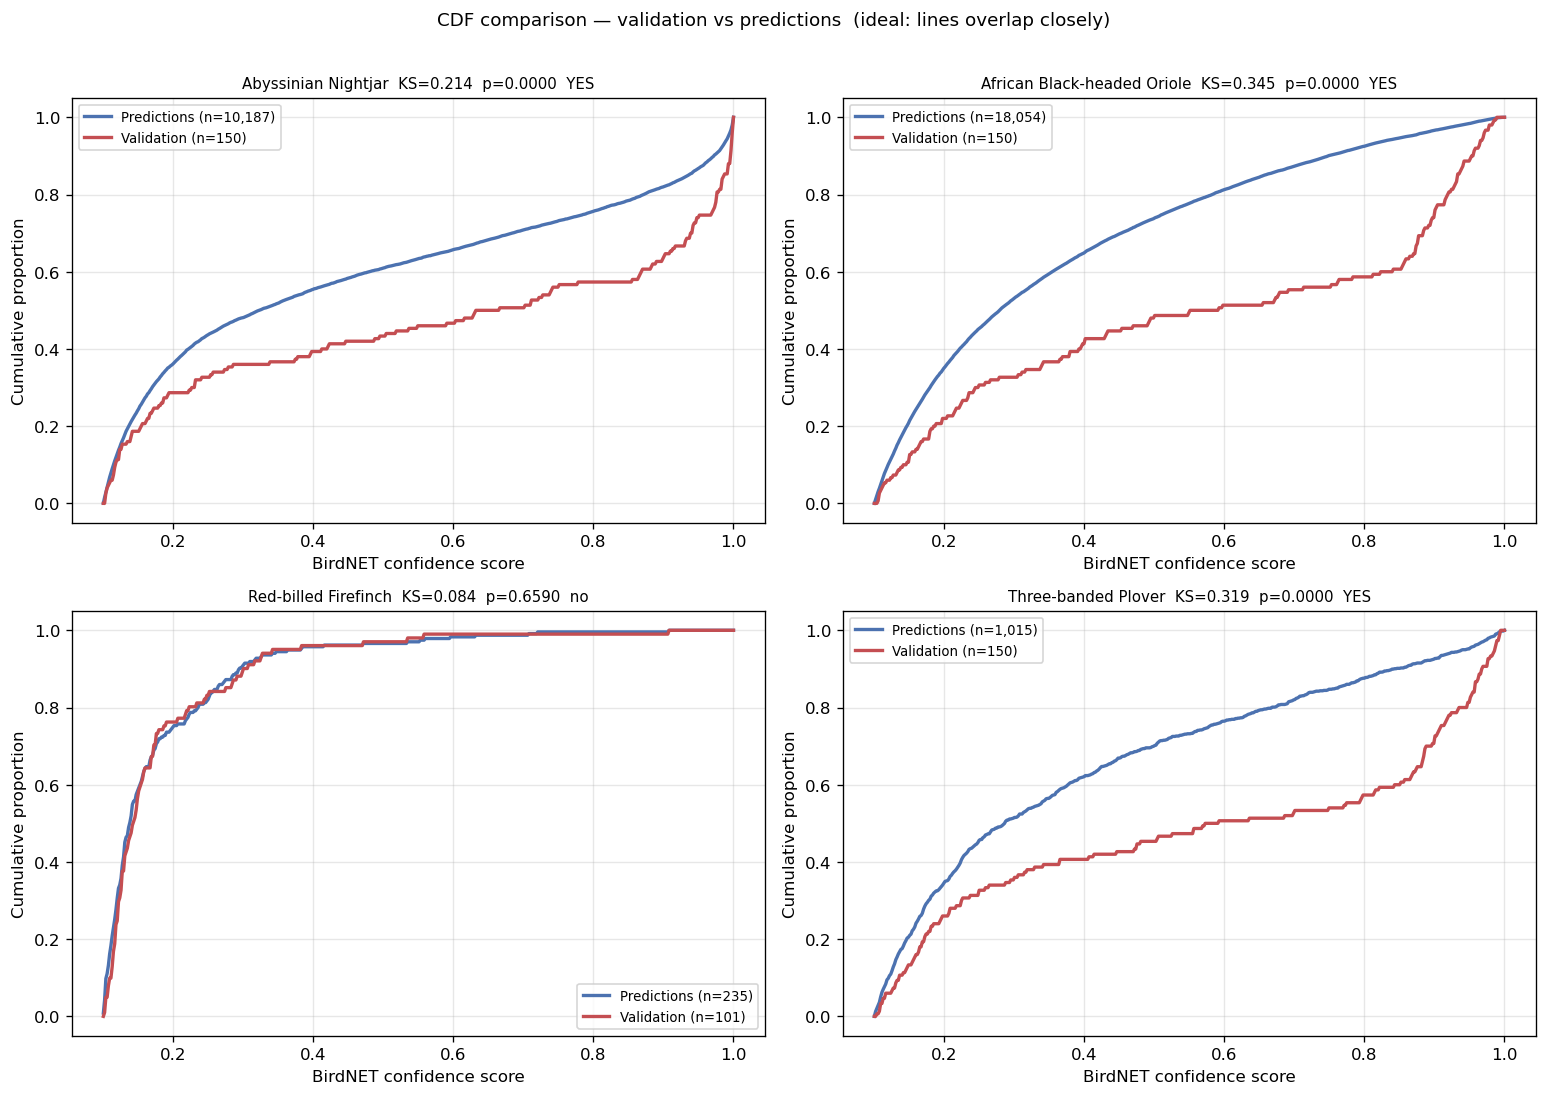

In [9]:
species_list = sorted(val['common_name'].unique())
ks_results = []

for sp in species_list:
    v_sc = val[val['common_name']  == sp]['confidence'].values
    p_sc = pred[pred['common_name'] == sp]['confidence'].values
    ks_stat, ks_p = stats.ks_2samp(v_sc, p_sc)
    ks_results.append({
        'species'        : sp,
        'n_validation'   : len(v_sc),
        'n_predictions'  : len(p_sc),
        'KS_statistic'   : round(ks_stat, 4),
        'p_value'        : round(ks_p,   4),
        'reject_H0_0.05' : 'YES' if ks_p < 0.05 else 'no'
    })

ks_df = pd.DataFrame(ks_results)
display(ks_df)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, sp in enumerate(species_list):
    ax   = axes.flatten()[i]
    v_sc = val[val['common_name']  == sp]['confidence'].values
    p_sc = pred[pred['common_name'] == sp]['confidence'].values
    xs   = np.linspace(0.1, 1.0, 500)
    ax.plot(xs, [(p_sc <= x).mean() for x in xs], color='#4C72B0', lw=2, label=f'Predictions (n={len(p_sc):,})')
    ax.plot(xs, [(v_sc <= x).mean() for x in xs], color='#C44E52', lw=2, label=f'Validation (n={len(v_sc)})')
    row = ks_df[ks_df['species'] == sp].iloc[0]
    ax.set_title(f'{sp}  KS={row["KS_statistic"]:.3f}  p={row["p_value"]:.4f}  {row["reject_H0_0.05"]}', fontsize=9)
    ax.set_xlabel('BirdNET confidence score')
    ax.set_ylabel('Cumulative proportion')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('CDF comparison — validation vs predictions  (ideal: lines overlap closely)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Score Bin Coverage

Divides the score range into 10 bins and checks:
1. Any bins with zero validation clips? (Red shading — threshold in those ranges is extrapolated, not empirical)
2. Are validation proportions per bin consistent with prediction proportions? (Chi-squared test)

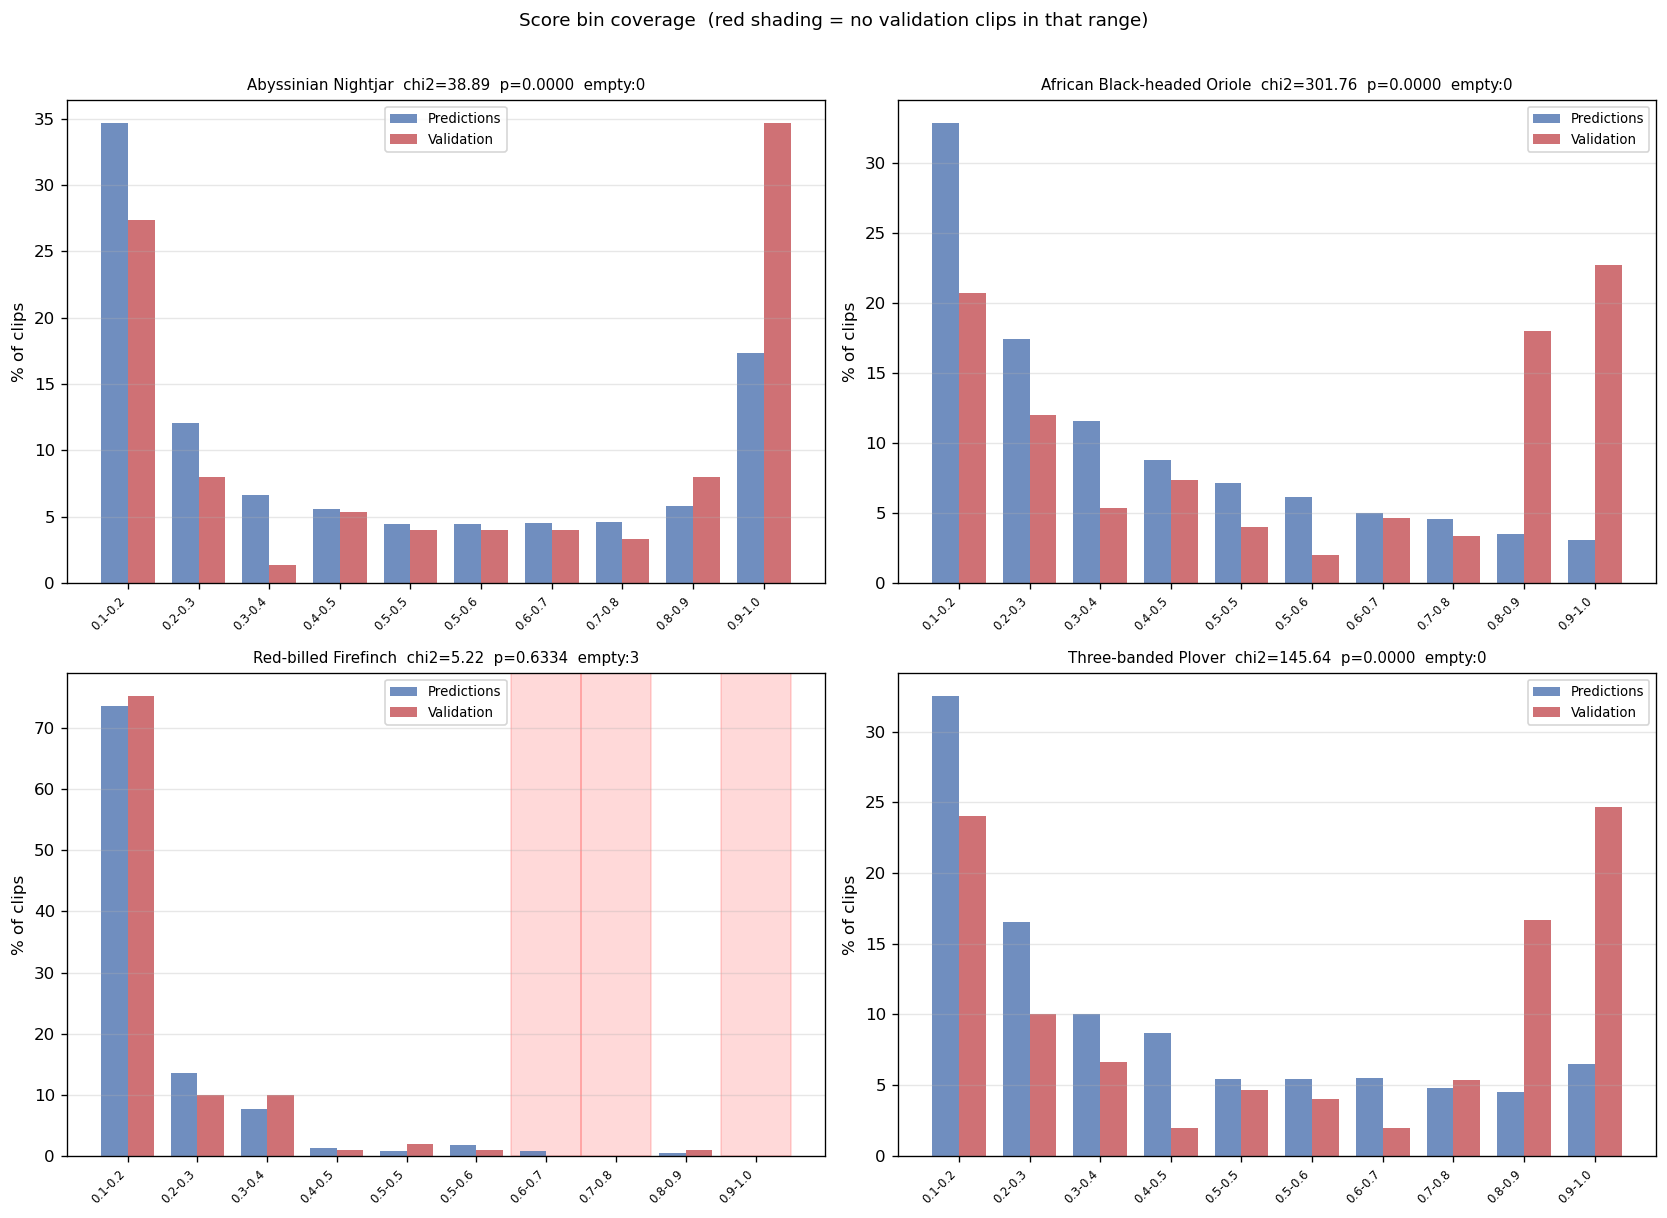


Chi-squared results (H0: validation proportionally sampled):


,species,bins_with_no_val,chi2,p_value,proportional
0,Abyssinian Nightjar,0,38.8890,0.0000,NO
1,African Black-headed Oriole,0,301.7560,0.0000,NO
2,Red-billed Firefinch,3,5.2180,0.6334,YES
3,Three-banded Plover,0,145.6420,0.0000,NO


In [10]:
N_BINS = 10
bins   = np.linspace(0.1, 1.0, N_BINS + 1)
labels = [f'{bins[j]:.1f}-{bins[j+1]:.1f}' for j in range(N_BINS)]
chi2_results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, sp in enumerate(species_list):
    ax  = axes.flatten()[i]
    v_c = np.histogram(val[val['common_name']  == sp]['confidence'].values, bins=bins)[0]
    p_c = np.histogram(pred[pred['common_name'] == sp]['confidence'].values, bins=bins)[0]
    x   = np.arange(N_BINS)
    w   = 0.38
    ax.bar(x-w/2, p_c/p_c.sum()*100, w, label='Predictions', color='#4C72B0', alpha=0.8)
    ax.bar(x+w/2, v_c/v_c.sum()*100, w, label='Validation',  color='#C44E52', alpha=0.8)
    for j, vc in enumerate(v_c):
        if vc == 0:
            ax.axvspan(j-0.5, j+0.5, alpha=0.15, color='red', zorder=0)
    exp  = p_c/p_c.sum()*v_c.sum()
    mask = exp > 0
    if mask.sum() >= 2:
        chi2, p_chi2 = stats.chisquare(v_c[mask], f_exp=exp[mask])
    else:
        chi2, p_chi2 = np.nan, np.nan
    empty = (v_c == 0).sum()
    chi2_results.append({
        'species'         : sp,
        'bins_with_no_val': empty,
        'chi2'            : round(chi2, 3)  if not np.isnan(chi2)  else 'N/A',
        'p_value'         : round(p_chi2,4) if not np.isnan(p_chi2) else 'N/A',
        'proportional'    : ('YES' if p_chi2 >= 0.05 else 'NO') if not np.isnan(p_chi2) else 'N/A'
    })
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    ax.set_ylabel('% of clips')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
    title = f'{sp}  chi2={chi2:.2f}  p={p_chi2:.4f}  empty:{empty}' if not np.isnan(chi2) else f'{sp}  empty:{empty}'
    ax.set_title(title, fontsize=9)
plt.suptitle('Score bin coverage  (red shading = no validation clips in that range)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()
print('\nChi-squared results (H0: validation proportionally sampled):')
display(pd.DataFrame(chi2_results))

### 6.3 Site Coverage

Checks what proportion of the 43 prediction sites have at least one validated clip. Sites with high prediction volume but no validation are the biggest generalisation risk.

Prediction sites         : 43
Sites with validation    : 32 (74.4%)
Sites with NO validation : 11
  -> ['RBS26', 'RBS28', 'RBS31', 'RBS37', 'RBS41', 'RBS42', 'RBS43', 'RBS54', 'RBS67', 'RBS69', 'RBS73']

-- Per-species --
  Abyssinian Nightjar                : val=15 pred=27 covered=15 (56%)
  African Black-headed Oriole        : val=14 pred=35 covered=14 (40%)
  Red-billed Firefinch               : val=22 pred=31 covered=22 (71%)
  Three-banded Plover                : val=9 pred=22 covered=9 (41%)


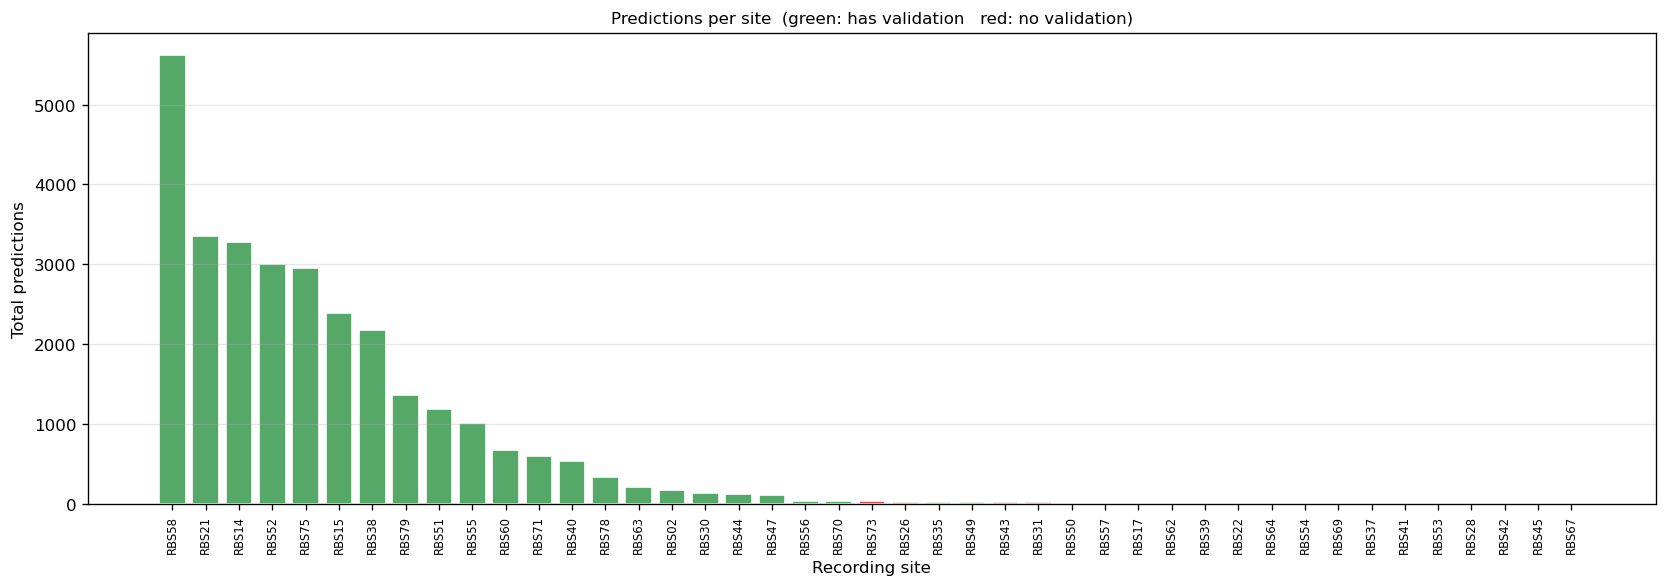

In [11]:
val['site'] = val['filename'].apply(
    lambda f: str(f).replace('.wav','').split('_')[2] if len(str(f).split('_')) >= 3 else None
)
pred_sites = set(pred['folder'].unique())
val_sites  = set(val['site'].dropna().unique())
covered    = val_sites & pred_sites

print(f'Prediction sites         : {len(pred_sites)}')
print(f'Sites with validation    : {len(covered)} ({100*len(covered)/len(pred_sites):.1f}%)')
print(f'Sites with NO validation : {len(pred_sites - val_sites)}')
if pred_sites - val_sites:
    print(f'  -> {sorted(pred_sites - val_sites)}')

print('\n-- Per-species --')
for sp in species_list:
    vs = set(val[val['common_name']  == sp]['site'].dropna().unique())
    ps = set(pred[pred['common_name'] == sp]['folder'].unique())
    print(f'  {sp:<35}: val={len(vs)} pred={len(ps)} covered={len(vs&ps)} ({100*len(vs&ps)/max(1,len(ps)):.0f}%)')

spc = pred.groupby('folder').size().reset_index(name='n').sort_values('n', ascending=False)
spc['validated'] = spc['folder'].isin(val_sites)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(spc['folder'], spc['n'],
       color=['#55A868' if v else '#C44E52' for v in spc['validated']],
       edgecolor='white')
ax.set_xlabel('Recording site')
ax.set_ylabel('Total predictions')
ax.set_title('Predictions per site  (green: has validation   red: no validation)', fontsize=10)
ax.tick_params(axis='x', rotation=90, labelsize=7)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.4 Prevalence and Score Separation

**Prevalence:** TP rate in the validation set. If the ornithologist deliberately balanced TPs and FPs (~50/50), calibrated probabilities will not reflect real-world precision and the threshold will be too conservative.

**Score separation:** Mean TP score minus mean FP score. Near zero means BirdNET's scores carry no useful signal for that species — no threshold will achieve 99% precision.

,species,n_validated,n_tp,n_fp,tp_rate,mean_score_TP,mean_score_FP,score_sep_TP_minus_FP
0,Abyssinian Nightjar,150,117,33,0.7800,0.7110,0.1530,0.5570
1,African Black-headed Oriole,150,150,0,1.0000,0.5670,NaN,NaN
2,Red-billed Firefinch,101,6,95,0.0590,0.3010,0.1740,0.1260
3,Three-banded Plover,150,149,1,0.9930,0.5750,0.2640,0.3110


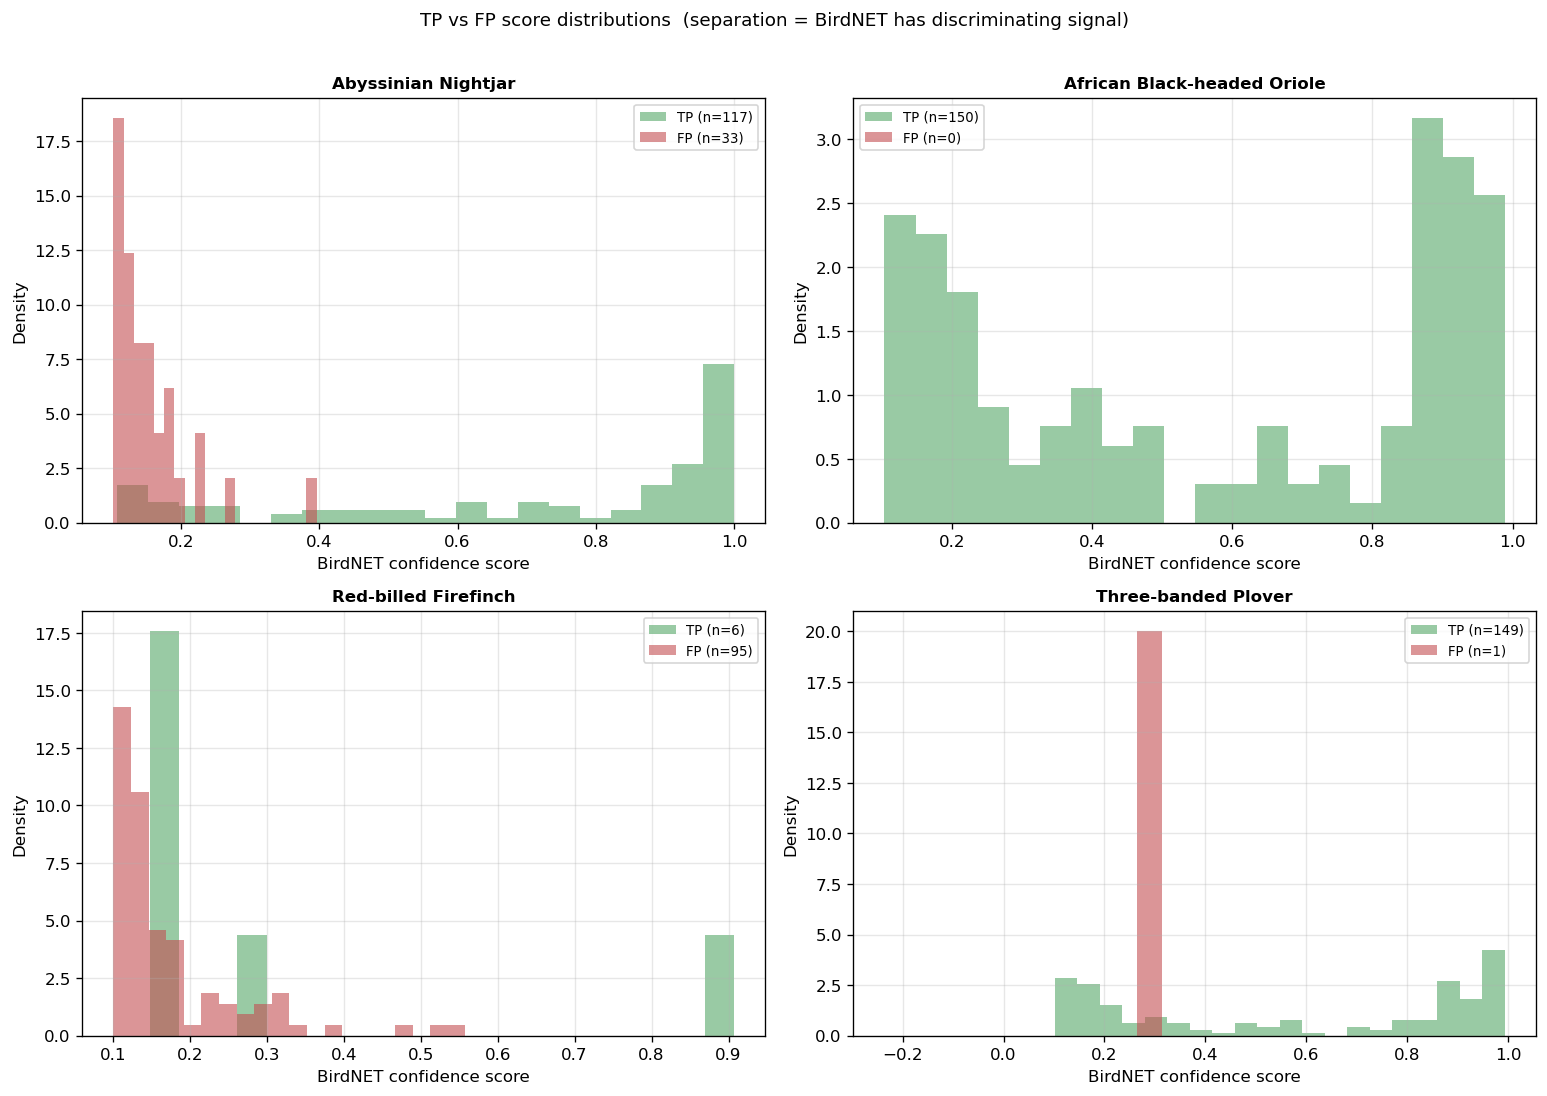

In [12]:
prev_rows = []
for sp in species_list:
    d    = val[val['common_name'] == sp]
    n_tp = d['outcome'].sum()
    tp_m = d[d['outcome'] == 1]['confidence'].mean()
    fp_m = d[d['outcome'] == 0]['confidence'].mean()
    prev_rows.append({
        'species'              : sp,
        'n_validated'          : len(d),
        'n_tp'                 : int(n_tp),
        'n_fp'                 : int(len(d) - n_tp),
        'tp_rate'              : round(n_tp / len(d), 3),
        'mean_score_TP'        : round(tp_m, 3) if not np.isnan(tp_m) else None,
        'mean_score_FP'        : round(fp_m, 3) if not np.isnan(fp_m) else None,
        'score_sep_TP_minus_FP': round(tp_m - fp_m, 3) if (not np.isnan(tp_m) and not np.isnan(fp_m)) else None
    })
prev_df = pd.DataFrame(prev_rows)
display(prev_df)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for i, sp in enumerate(species_list):
    ax = axes.flatten()[i]
    d  = val[val['common_name'] == sp]
    ax.hist(d[d['outcome'] == 1]['confidence'].values, bins=20, alpha=0.6,
            color='#55A868', density=True, label=f'TP (n={int(d["outcome"].sum())})')
    ax.hist(d[d['outcome'] == 0]['confidence'].values, bins=20, alpha=0.6,
            color='#C44E52', density=True, label=f'FP (n={int((d["outcome"]==0).sum())})')
    ax.set_xlabel('BirdNET confidence score')
    ax.set_ylabel('Density')
    ax.set_title(sp, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('TP vs FP score distributions  (separation = BirdNET has discriminating signal)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

### 6.5 Sample Size Adequacy — Events Per Variable (EPV)

With 1 predictor (logit score), EPV = number of true positives.
- **EPV < 10** — threshold unreliable; use fallback rule
- **EPV < 20** — marginal; flag in outputs
- **EPV >= 20** — adequate for logistic regression

In [13]:
epv_rows = []
for sp in species_list:
    d    = val[val['common_name'] == sp]
    n_tp = int(d['outcome'].sum())
    status = ('INSUFFICIENT' if n_tp < 10
              else 'MARGINAL'    if n_tp < 20
              else 'ADEQUATE')
    epv_rows.append({
        'species': sp, 'n_total': len(d),
        'n_tp': n_tp, 'n_fp': int(len(d)-n_tp),
        'EPV': n_tp, 'status': status
    })
epv_df = pd.DataFrame(epv_rows)
display(epv_df)

,species,n_total,n_tp,n_fp,EPV,status
0,Abyssinian Nightjar,150,117,33,117,ADEQUATE
1,African Black-headed Oriole,150,150,0,150,ADEQUATE
2,Red-billed Firefinch,101,6,95,6,INSUFFICIENT
3,Three-banded Plover,150,149,1,149,ADEQUATE


### 6.6 Representativeness Summary

All five checks in one table — the decision table for modelling. Determines which species proceed with standard logistic regression and which need a fallback or caveat.

In [14]:
chi2_df = pd.DataFrame(chi2_results)
summary_rows = []
for sp in species_list:
    ks_r   = ks_df[ks_df['species']   == sp].iloc[0]
    chi_r  = chi2_df[chi2_df['species'] == sp].iloc[0]
    epv_r  = epv_df[epv_df['species']  == sp].iloc[0]
    prev_r = prev_df[prev_df['species'] == sp].iloc[0]
    summary_rows.append({
        'species'               : sp,
        'KS_distribution_OK'    : 'NO' if ks_r['reject_H0_0.05'] == 'YES' else 'OK',
        'bin_coverage_OK'       : 'NO' if chi_r['bins_with_no_val'] > 0   else 'OK',
        'EPV_status'            : epv_r['status'],
        'TP_FP_score_separation': prev_r['score_sep_TP_minus_FP'],
    })
print('=== REPRESENTATIVENESS SUMMARY ===')
display(pd.DataFrame(summary_rows))

=== REPRESENTATIVENESS SUMMARY ===


,species,KS_distribution_OK,bin_coverage_OK,EPV_status,TP_FP_score_separation
0,Abyssinian Nightjar,NO,OK,ADEQUATE,0.5570
1,African Black-headed Oriole,NO,OK,ADEQUATE,NaN
2,Red-billed Firefinch,OK,NO,INSUFFICIENT,0.1260
3,Three-banded Plover,NO,OK,ADEQUATE,0.3110


---
## 7. Modelling Pipeline

### Overview

**Single method: logistic regression on logit-transformed confidence scores**, as prescribed by Wood & Kahl (2024). The representativeness analysis in Section 6 was the diagnostic step — this section is the implementation.

---

### Stage 1 — Logit Transform
**What:** `logit_score = ln(confidence / (1 - confidence))`  
**Why:** BirdNET squeezes its internal activation through a sigmoid into [0, 1], compressing the scale non-linearly. The gap between 0.95 and 0.99 represents a far larger signal jump than 0.50 to 0.54. A logistic regression on raw scores cannot model this and breaks down at the extremes where our threshold sits. The logit undoes the sigmoid, returning scores to a linear scale.  
*(Already applied in Section 5 — `logit_score` column is ready.)*

---

### Stage 2 — Fit Logistic Regression Per Species
**What:** For each species: `pr(correct) = sigmoid(b0 + b1 * logit_score)`  
**Fallback:** If only one class exists in validation (all correct or all wrong), logistic regression cannot fit. Threshold defaults to the minimum observed confidence score, flagged as unreliable.

---

### Stage 3 — Derive the 99% Precision Threshold
**What:** Solve the fitted model analytically:  
```
logit_threshold      = ( ln(0.99 / 0.01) - b0 ) / b1
confidence_threshold = sigmoid(logit_threshold)
```
**Why 99%?** At most 1 false positive per 100 observations. In biodiversity monitoring, false positives persist in databases for years and cost more than missed detections.

---

### Stage 4 — Diagnostic Visualisations
Three 2x2 plots (one panel per species):
- **Calibration curve** — fitted probability curve + 99% threshold line
- **Score distributions** — TP vs FP histograms + threshold line
- **Precision-recall curve** — tradeoff; shows recall cost of demanding 99% precision

---

### Stage 5 — Label All Predictions
`observation = 1` if `confidence >= threshold`, `0` if below, `NULL` if threshold unreliable.  
Outputs: `birdnet_predictions_labelled.csv` + `species_thresholds.csv`

---

### Stage 1 — Logit Transform Verification

Already applied in Section 5. We confirm the transform behaves as expected: 0.5 maps to 0, scores above 0.5 go positive, scores below go negative. The key property — stretching at the extremes — is visible in the scatter plot.

Logit transform reference table:


,confidence,logit_score
0,0.1000,-2.1972
1,0.3000,-0.8473
2,0.5000,0.0000
3,0.7000,0.8473
4,0.9000,2.1972
5,0.9500,2.9444
6,0.9900,4.5951


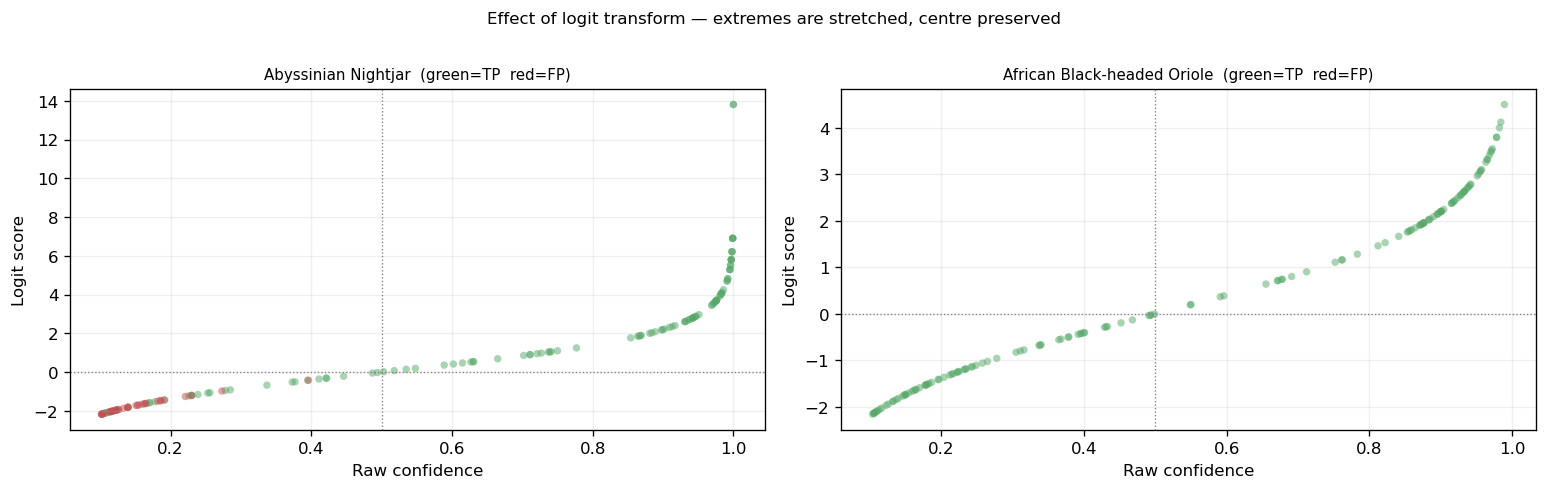

In [15]:
check = pd.DataFrame({'confidence': [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]})
check['logit_score'] = safe_logit(check['confidence'].values).round(4)
print('Logit transform reference table:')
display(check)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i, sp in enumerate(species_list[:2]):
    ax  = axes[i]
    d   = val[val['common_name'] == sp]
    clr = d['outcome'].map({1: '#55A868', 0: '#C44E52'})
    ax.scatter(d['confidence'], d['logit_score'], c=clr, alpha=0.5, s=20, edgecolors='none')
    ax.axvline(0.5, color='grey', linestyle=':', lw=0.8)
    ax.axhline(0,   color='grey', linestyle=':', lw=0.8)
    ax.set_xlabel('Raw confidence')
    ax.set_ylabel('Logit score')
    ax.set_title(f'{sp}  (green=TP  red=FP)', fontsize=9)
    ax.grid(True, alpha=0.2)
plt.suptitle('Effect of logit transform — extremes are stretched, centre preserved', fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

### Stage 2 — Fit Logistic Regression Per Species

In [16]:
TARGET_P = 0.99

def fit_logistic_logit(X_logit, y):
    """Logistic regression on logit-transformed BirdNET scores (Wood & Kahl 2024)."""
    lr = LogisticRegression(solver='lbfgs', max_iter=1000)
    lr.fit(X_logit.reshape(-1, 1), y)
    return lr

def threshold_from_model(model, target_p=TARGET_P):
    """
    Solve pr(correct) = target_p analytically.
      logit_t = (logit(target_p) - b0) / b1
      confidence_threshold = sigmoid(logit_t)
    Returns None if b1 = 0 (flat curve, no discriminating signal).
    """
    b0, b1 = model.intercept_[0], model.coef_[0][0]
    if b1 == 0:
        return None
    logit_t = (np.log(target_p / (1 - target_p)) - b0) / b1
    return float(expit(logit_t))

species_models     = {}
species_thresholds = {}
species_reliable   = {}
fit_results        = []

for sp in species_list:
    d       = val[val['common_name'] == sp].copy()
    y       = d['outcome'].values
    X_raw   = d['confidence'].values
    X_logit = d['logit_score'].values
    n_tp    = int(y.sum())
    n_fp    = int((y == 0).sum())

    print(f'-- {sp}  (n={len(y)}, TP={n_tp}, FP={n_fp})')

    # Fallback: only one class present
    if len(np.unique(y)) < 2:
        min_conf = float(X_raw.min())
        print(f'   Single class -> fallback threshold = {min_conf:.4f}')
        species_models[sp]     = None
        species_thresholds[sp] = min_conf
        species_reliable[sp]   = False
        fit_results.append({
            'species': sp, 'n_validated': len(y), 'n_tp': n_tp, 'n_fp': n_fp,
            'intercept_b0': None, 'coef_logit_b1': None,
            'threshold_p99': round(min_conf, 4), 'threshold_reliable': False,
            'note': 'Fallback: single class'
        })
        continue

    model = fit_logistic_logit(X_logit, y)
    thr   = threshold_from_model(model)
    b0    = round(model.intercept_[0], 6)
    b1    = round(model.coef_[0][0],   6)

    species_models[sp]     = model
    species_thresholds[sp] = thr
    species_reliable[sp]   = thr is not None

    thr_str = f'{thr:.4f}' if thr is not None else 'None (curve never reaches 99%)'
    print(f'   b0={b0}  b1={b1}  ->  threshold={thr_str}')

    fit_results.append({
        'species': sp, 'n_validated': len(y), 'n_tp': n_tp, 'n_fp': n_fp,
        'intercept_b0': b0, 'coef_logit_b1': b1,
        'threshold_p99': round(thr, 4) if thr else None,
        'threshold_reliable': thr is not None, 'note': ''
    })

print('\nModels fitted.')
display(pd.DataFrame(fit_results))

-- Abyssinian Nightjar  (n=150, TP=117, FP=33)
   b0=2.632614  b1=1.726746  ->  threshold=0.7570
-- African Black-headed Oriole  (n=150, TP=150, FP=0)
   Single class -> fallback threshold = 0.1040
-- Red-billed Firefinch  (n=101, TP=6, FP=95)
   b0=-1.642914  b1=0.790406  ->  threshold=0.9996
-- Three-banded Plover  (n=150, TP=149, FP=1)
   b0=5.022928  b1=0.371231  ->  threshold=0.2401

Models fitted.


,species,n_validated,n_tp,n_fp,intercept_b0,coef_logit_b1,threshold_p99,threshold_reliable,note
0,Abyssinian Nightjar,150,117,33,2.6326,1.7267,0.7570,True,
1,African Black-headed Oriole,150,150,0,NaN,NaN,0.1040,False,Fallback: single class
2,Red-billed Firefinch,101,6,95,-1.6429,0.7904,0.9996,True,
3,Three-banded Plover,150,149,1,5.0229,0.3712,0.2401,True,


### Stage 3 — Derive the 99% Threshold & Evaluate the Model

Thresholds were derived analytically in the loop above. Here we compute model quality metrics (AUC, Brier score, Log-loss) and save the threshold table — the operational artefact the Tech Team loads into the production database.

- **AUC** — how well logit scores rank TPs above FPs (1.0 = perfect, 0.5 = random)
- **Brier score** — mean squared error of predicted probabilities (0 = perfect)
- **Log-loss** — like Brier but penalises confidently wrong predictions more heavily

In [17]:
eval_rows   = []
thresh_rows = []

for sp in species_list:
    d       = val[val['common_name'] == sp]
    y       = d['outcome'].values
    X_logit = d['logit_score'].values
    model   = species_models.get(sp)
    thr     = species_thresholds.get(sp)
    reliable= species_reliable.get(sp, False)

    # Evaluation metrics
    if model is None:
        auc, brier, ll = None, None, None
        note = 'Fallback - metrics N/A'
    else:
        probs = model.predict_proba(X_logit.reshape(-1,1))[:,1]
        try:    auc   = round(roc_auc_score(y, probs), 4)
        except: auc   = None
        try:    brier = round(brier_score_loss(y, probs), 4)
        except: brier = None
        try:    ll    = round(log_loss(y, probs), 4)
        except: ll    = None
        note = '' if thr else 'Curve never reaches 99%'

    eval_rows.append({
        'species': sp, 'threshold_p99': round(thr,4) if thr else None,
        'reliable': reliable, 'AUC': auc, 'Brier': brier, 'LogLoss': ll, 'note': note
    })

    # Threshold table
    thresh_rows.append({
        'common_name'       : sp,
        'birdnet_version'   : d['vBirdNET'].iloc[0] if len(d) else 'v2.4',
        'n_validated'       : len(d),
        'n_true_positives'  : int(d[d['outcome']==1].shape[0]),
        'method'            : 'logistic_logit_score' if model else 'fallback_min_confidence',
        'intercept_b0'      : round(model.intercept_[0],6) if model else None,
        'coef_logit_b1'     : round(model.coef_[0][0],6)   if model else None,
        'threshold_p99'     : round(thr,6) if thr else None,
        'threshold_reliable': model is not None,
    })

print('=== MODEL EVALUATION ===')
display(pd.DataFrame(eval_rows))

thresh_df = pd.DataFrame(thresh_rows)
thresh_df.to_csv(os.path.join(OUT_DIR, 'species_thresholds.csv'), index=False)
print('\nSaved -> outputs/bird/species_thresholds.csv')
display(thresh_df)

=== MODEL EVALUATION ===


,species,threshold_p99,reliable,AUC,Brier,LogLoss,note
0,Abyssinian Nightjar,0.7570,True,0.9307,0.0855,0.2538,
1,African Black-headed Oriole,0.1040,False,NaN,NaN,NaN,Fallback - metrics N/A
2,Red-billed Firefinch,0.9996,True,0.7079,0.0499,0.2046,
3,Three-banded Plover,0.2401,True,0.6644,0.0066,0.0376,



Saved -> outputs/bird/species_thresholds.csv


,common_name,birdnet_version,n_validated,n_true_positives,method,intercept_b0,coef_logit_b1,threshold_p99,threshold_reliable
0,Abyssinian Nightjar,v2.4,150,117,logistic_logit_score,2.6326,1.7267,0.7570,True
1,African Black-headed Oriole,v2.4,150,150,fallback_min_confidence,NaN,NaN,0.1040,False
2,Red-billed Firefinch,v2.4,101,6,logistic_logit_score,-1.6429,0.7904,0.9996,True
3,Three-banded Plover,v2.4,150,149,logistic_logit_score,5.0229,0.3712,0.2401,True


### Stage 4 — Diagnostic Visualisations

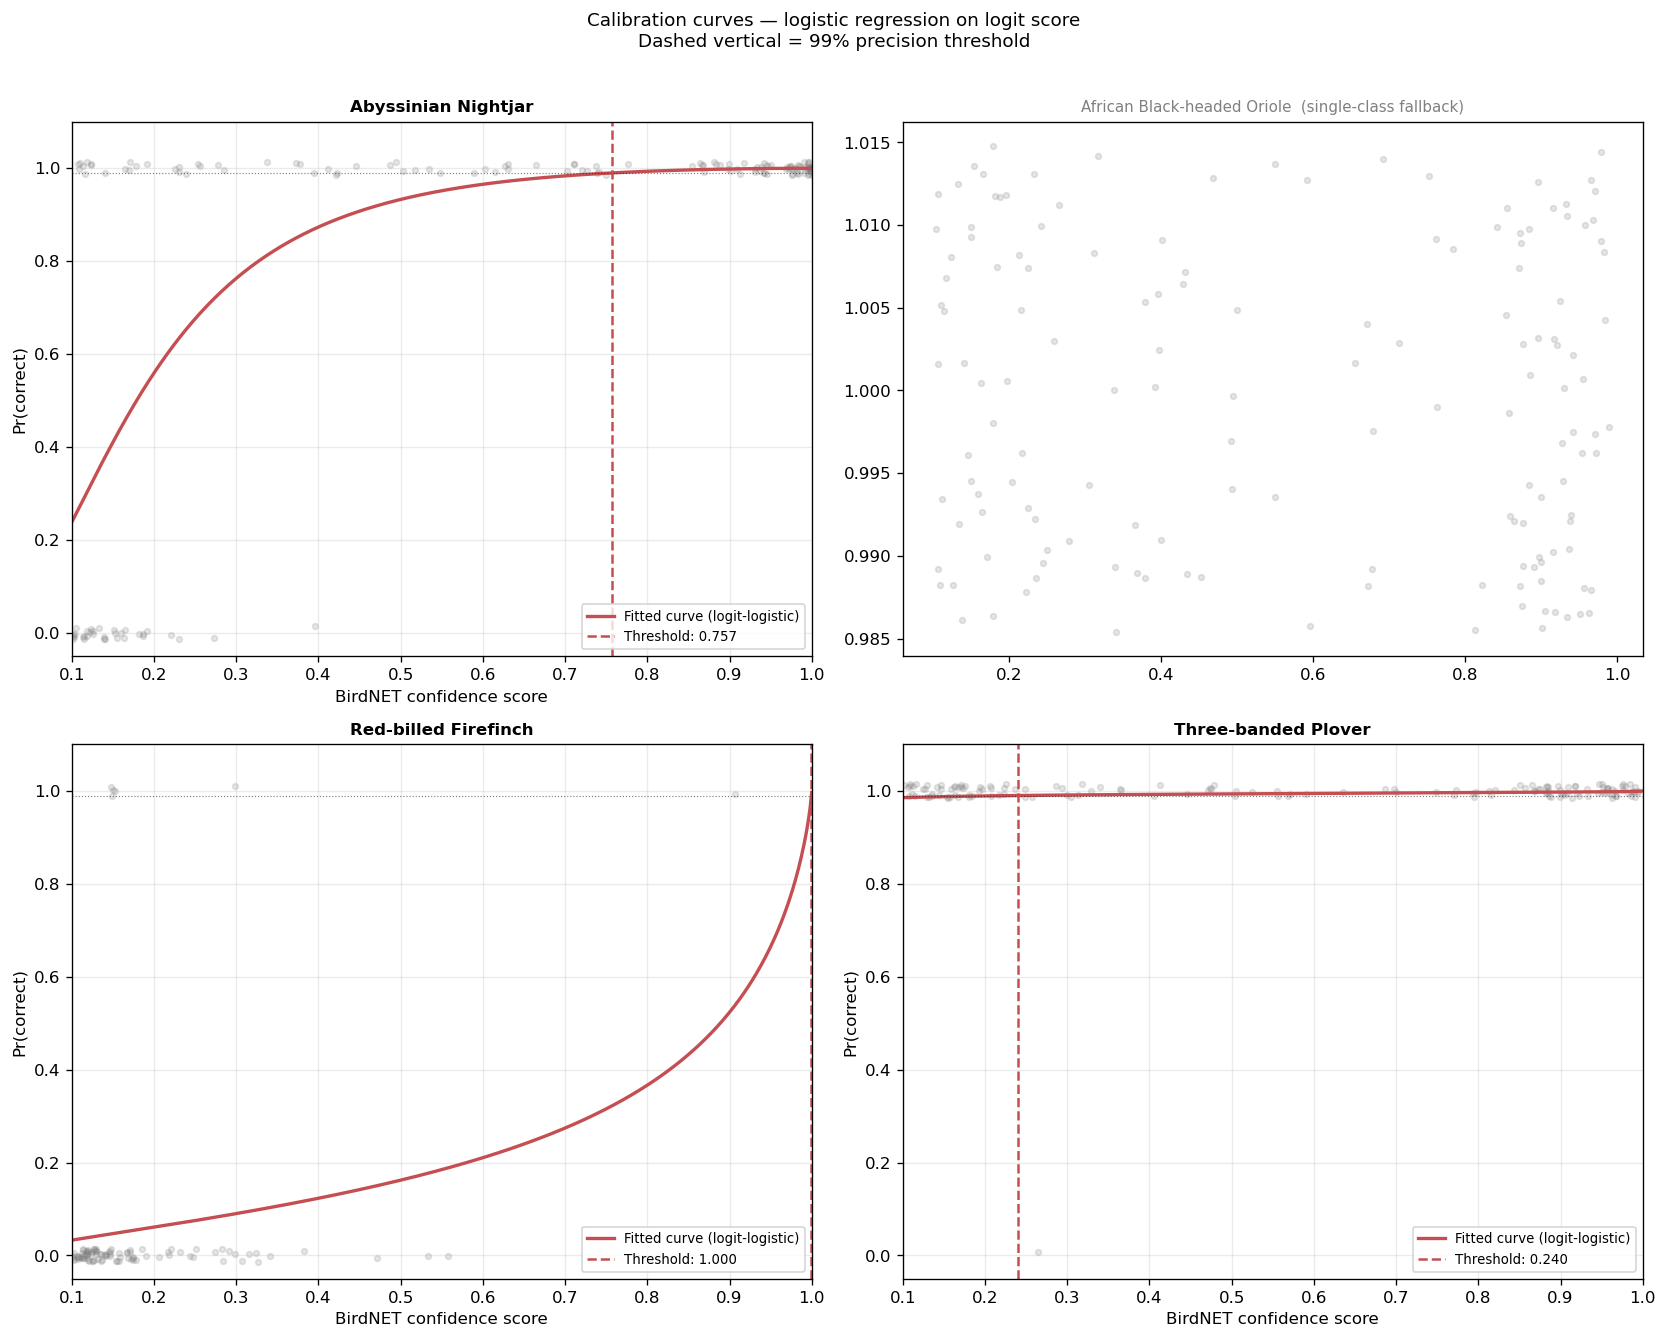

Saved -> outputs/bird/calibration_curves.png


In [18]:
# Plot 1: Calibration curves
# Fitted probability curve over the full score range.
# Grey dots = raw validation clips (jittered vertically).
# Dashed red vertical line = 99% threshold.
# The curve should rise steeply and cross 0.99 at the threshold.

xs_conf  = np.linspace(0.1, 0.9999, 500)
xs_logit = safe_logit(xs_conf)
rng      = np.random.default_rng(42)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for i, sp in enumerate(species_list):
    ax    = axes.flatten()[i]
    d     = val[val['common_name'] == sp]
    jit   = rng.uniform(-0.015, 0.015, len(d))
    ax.scatter(d['confidence'], d['outcome'].values + jit,
               alpha=0.2, s=12, color='grey', zorder=1)

    model = species_models.get(sp)
    if model is None:
        ax.set_title(f'{sp}  (single-class fallback)', fontsize=9, color='grey')
        continue

    probs = model.predict_proba(xs_logit.reshape(-1,1))[:,1]
    ax.plot(xs_conf, probs, color='#C44E52', lw=2,
            label='Fitted curve (logit-logistic)', zorder=2)
    ax.axhline(TARGET_P, color='black', linestyle=':', lw=0.7, alpha=0.5)
    thr = species_thresholds[sp]
    if thr and 0 < thr < 1:
        ax.axvline(thr, color='#C44E52', linestyle='--', lw=1.5,
                   label=f'Threshold: {thr:.3f}')
    ax.set_xlim(0.1, 1.0); ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel('BirdNET confidence score')
    ax.set_ylabel('Pr(correct)')
    ax.set_title(sp, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.25)

plt.suptitle('Calibration curves — logistic regression on logit score\nDashed vertical = 99% precision threshold',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'calibration_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/bird/calibration_curves.png')

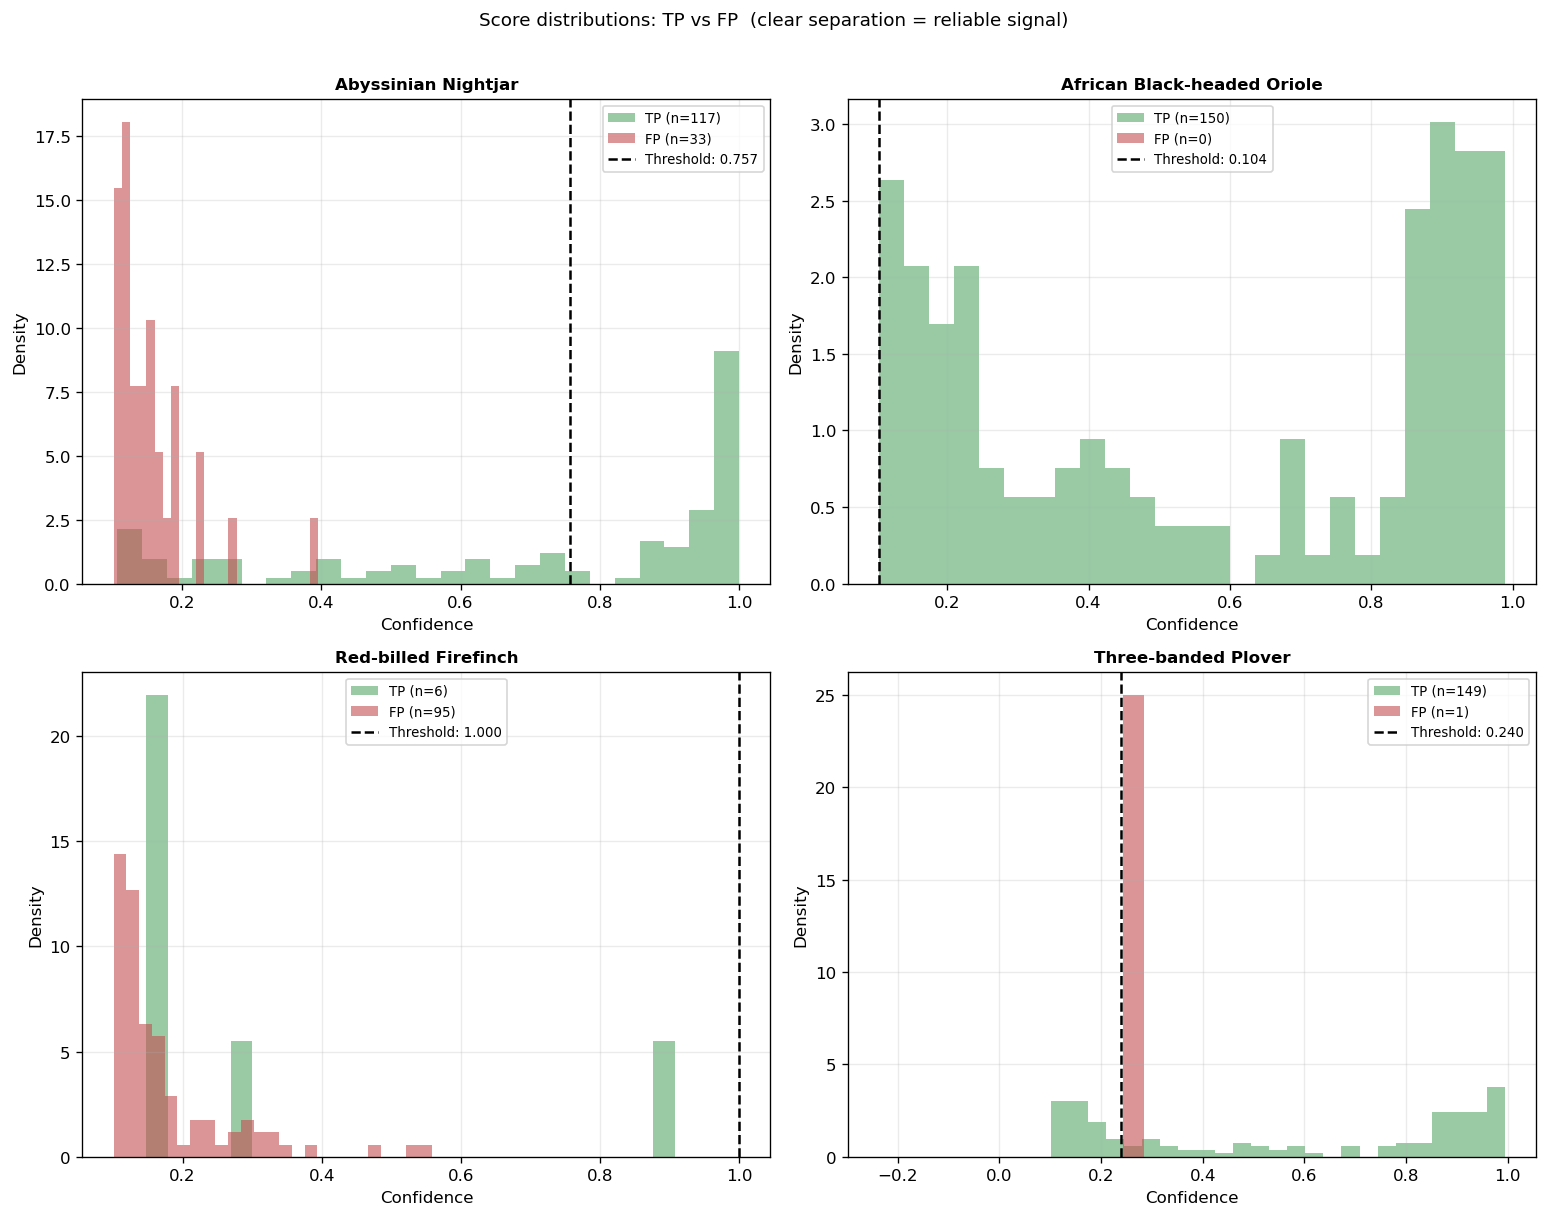

Saved -> outputs/bird/score_distributions.png


In [19]:
# Plot 2: Score distributions (TP vs FP)
# The threshold (black dashed) should sit where the green TP distribution dominates.
# Heavy overlap between green and red = poor signal for that species.

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for i, sp in enumerate(species_list):
    ax = axes.flatten()[i]
    d  = val[val['common_name'] == sp]
    ax.hist(d[d['outcome'] == 1]['confidence'].values, bins=25, alpha=0.6,
            color='#55A868', density=True, label=f'TP (n={int(d["outcome"].sum())})')
    ax.hist(d[d['outcome'] == 0]['confidence'].values, bins=25, alpha=0.6,
            color='#C44E52', density=True, label=f'FP (n={int((d["outcome"]==0).sum())})')
    thr = species_thresholds.get(sp)
    if thr and 0 < thr < 1:
        ax.axvline(thr, color='black', linestyle='--', lw=1.5, label=f'Threshold: {thr:.3f}')
    ax.set_xlabel('Confidence'); ax.set_ylabel('Density')
    ax.set_title(sp, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

plt.suptitle('Score distributions: TP vs FP  (clear separation = reliable signal)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'score_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/bird/score_distributions.png')

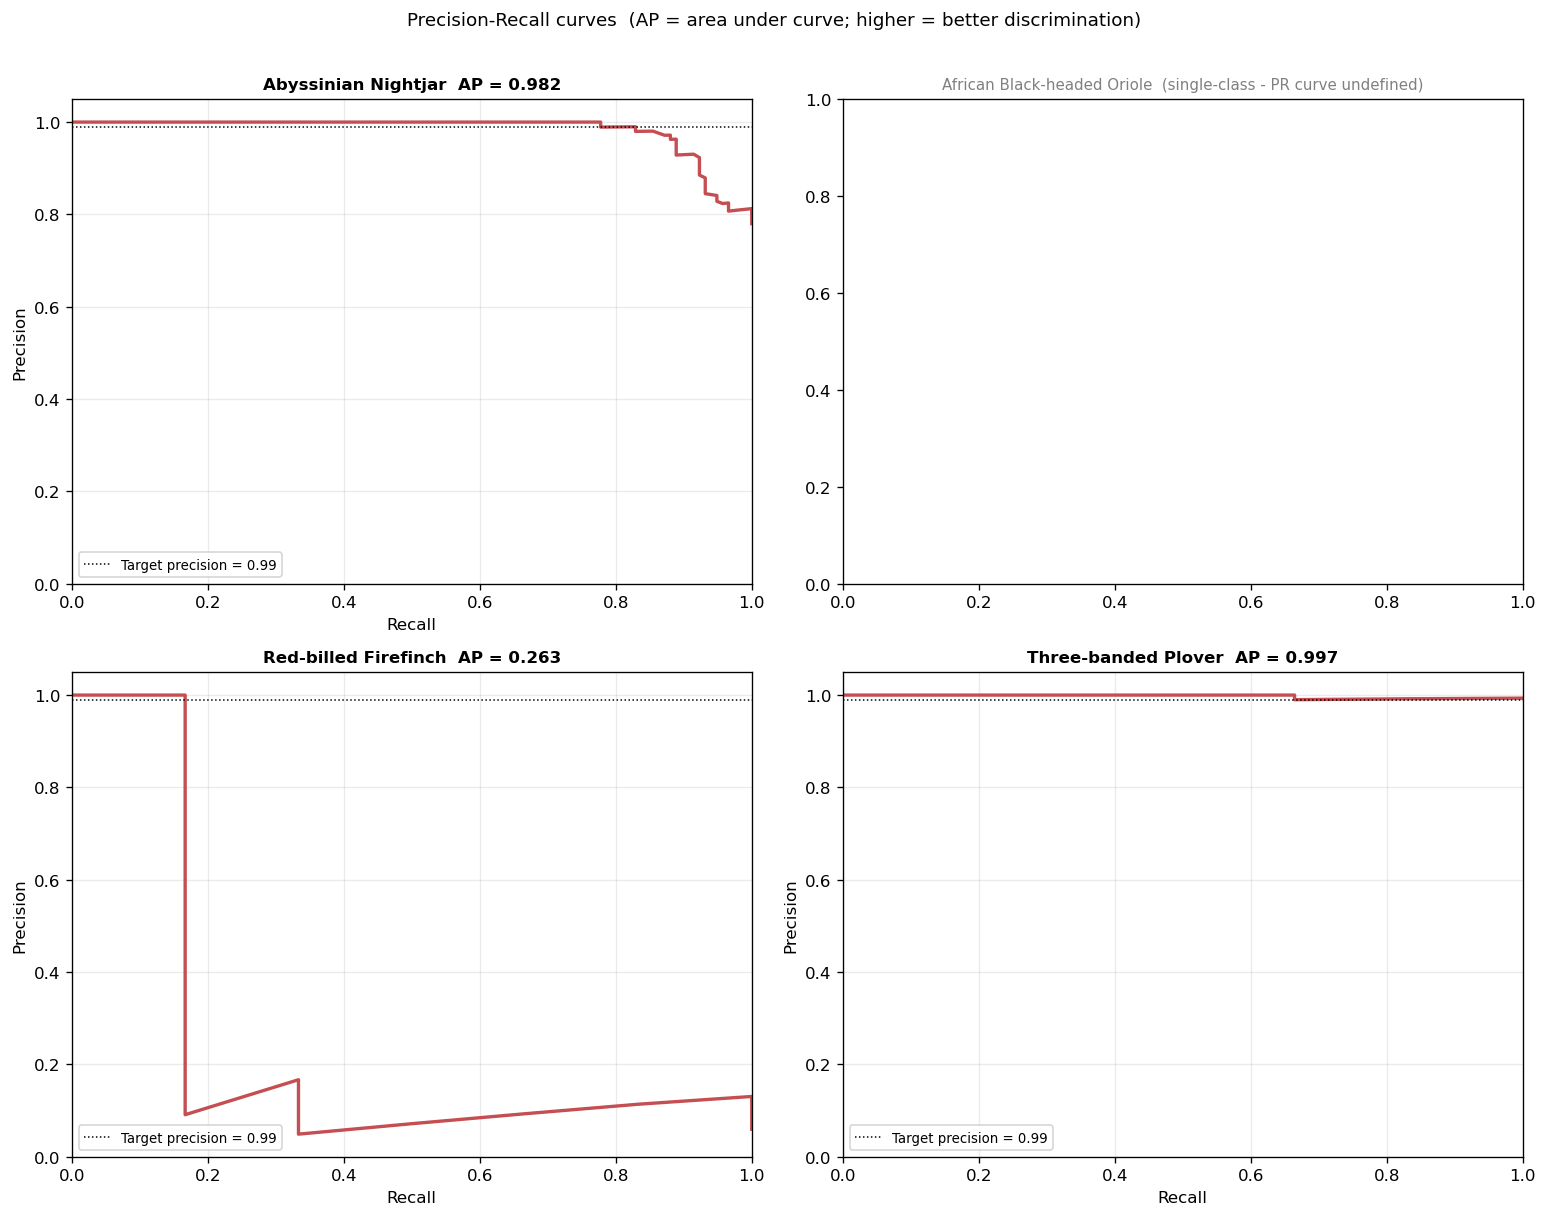

Saved -> outputs/bird/precision_recall_curves.png


In [20]:
# Plot 3: Precision-Recall curves
# The dashed horizontal at 0.99 shows the recall we retain at our target.
# Average Precision (AP) summarises the full curve.
# Low AP = BirdNET cannot distinguish TP from FP for that species at any threshold.

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for i, sp in enumerate(species_list):
    ax    = axes.flatten()[i]
    d     = val[val['common_name'] == sp]
    model = species_models.get(sp)
    if model is None:
        ax.set_title(f'{sp}  (single-class - PR curve undefined)', fontsize=9, color='grey')
        continue
    probs        = model.predict_proba(d['logit_score'].values.reshape(-1,1))[:,1]
    prec, rec, _ = precision_recall_curve(d['outcome'].values, probs)
    ap           = average_precision_score(d['outcome'].values, probs)
    ax.plot(rec, prec, color='#C44E52', lw=2)
    ax.axhline(TARGET_P, color='black', linestyle=':', lw=0.9,
               label=f'Target precision = {TARGET_P}')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{sp}  AP = {ap:.3f}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.set_xlim(0,1); ax.set_ylim(0,1.05)
    ax.grid(True, alpha=0.25)

plt.suptitle('Precision-Recall curves  (AP = area under curve; higher = better discrimination)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'precision_recall_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/bird/precision_recall_curves.png')

### Stage 5 — Label All Predictions

Apply species-specific thresholds to all 29,491 predictions.
- `observation = 1` if `confidence >= threshold` (confirmed observation)
- `observation = 0` if below threshold (sub-threshold prediction)
- `observation = NULL` if threshold is unreliable (needs manual review)

The rule is `>=` because a clip at exactly the threshold meets the 99% bar.

In [21]:
threshold_lookup = {
    row['common_name']: (row['threshold_p99'], row['threshold_reliable'])
    for _, row in thresh_df.iterrows()
}

def label_observation(row):
    entry = threshold_lookup.get(row['common_name'])
    if entry is None:
        return pd.NA
    thr, reliable = entry
    if not reliable or thr is None:
        return pd.NA
    return int(row['confidence'] >= thr)

pred['observation'] = pred.apply(label_observation, axis=1)

# Summary by species
rows = []
for sp in species_list:
    sp_df  = pred[pred['common_name'] == sp]
    n_pred = len(sp_df)
    n_obs  = (sp_df['observation'] == 1).sum()
    n_sub  = (sp_df['observation'] == 0).sum()
    n_null = sp_df['observation'].isna().sum()
    thr, rel = threshold_lookup.get(sp, (None, False))
    rows.append({
        'species'         : sp,
        'threshold'       : round(thr, 4) if thr else None,
        'reliable'        : rel,
        'n_predictions'   : n_pred,
        'n_observations'  : int(n_obs),
        'n_sub_threshold' : int(n_sub),
        'n_null_review'   : int(n_null),
        'pct_observations': round(100*n_obs/n_pred, 1) if n_pred > 0 else 0
    })

label_df = pd.DataFrame(rows)
display(label_df)

totals = label_df[['n_predictions','n_observations','n_sub_threshold','n_null_review']].sum()
print(f'\nTotal predictions  : {totals["n_predictions"]:,}')
print(f'Observations       : {totals["n_observations"]:,}  ({100*totals["n_observations"]/totals["n_predictions"]:.1f}%)')
print(f'Sub-threshold      : {totals["n_sub_threshold"]:,}')
print(f'Needs manual review: {totals["n_null_review"]:,}')

,species,threshold,reliable,n_predictions,n_observations,n_sub_threshold,n_null_review,pct_observations
0,Abyssinian Nightjar,0.7570,True,10187,2700,7487,0,26.5000
1,African Black-headed Oriole,0.1040,False,18054,0,0,18054,0.0000
2,Red-billed Firefinch,0.9996,True,235,0,235,0,0.0000
3,Three-banded Plover,0.2401,True,1015,570,445,0,56.2000



Total predictions  : 29,491
Observations       : 3,270  (11.1%)
Sub-threshold      : 8,167
Needs manual review: 18,054


In [22]:
# Save labelled predictions
pred.to_csv(os.path.join(OUT_DIR, 'birdnet_predictions_labelled.csv'), index=False)
print(f'Saved -> outputs/bird/birdnet_predictions_labelled.csv  ({len(pred):,} rows)')

# Site-level observation summary
site_summary = (
    pred[pred['observation'] == 1]
    .groupby(['folder', 'common_name'])
    .size()
    .reset_index(name='n_observations')
    .pivot(index='folder', columns='common_name', values='n_observations')
    .fillna(0).astype(int)
)
site_summary.to_csv(os.path.join(OUT_DIR, 'site_observation_summary.csv'))
print(f'Saved -> outputs/bird/site_observation_summary.csv  ({len(site_summary)} sites)')
display(site_summary.head(10))

Saved -> outputs/bird/birdnet_predictions_labelled.csv  (29,491 rows)
Saved -> outputs/bird/site_observation_summary.csv  (25 sites)


common_name,Abyssinian Nightjar,Three-banded Plover
folder,,
RBS02,0,1
RBS14,1086,0
RBS15,758,0
RBS17,0,1
RBS21,233,1
RBS26,1,0
RBS30,22,0
RBS38,3,0
RBS39,0,1
